#Eye Disease — CV/ML Engineer
**Requiere:** `split_index.csv` generado por `pipeline.ipynb` en Kaggle.

**Flujo:**
1. Instalar deps y descargar dataset de Kaggle
2. Subir `split_index.csv` con el botón que aparece en la celda
3. El notebook remapea las rutas automáticamente
4. Entrenar EfficientNetB0, Grad-CAM, MC Dropout



## 1 · Setup

In [11]:
%%capture
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

In [12]:
import json, warnings, os
from pathlib import Path
from copy import deepcopy

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, ConfusionMatrixDisplay)
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

RESULTS_DIR = Path('/content/results')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Device: {DEVICE}')
print('CUDA disponible:', torch.cuda.is_available())

Device: cuda
CUDA disponible: True


## 2 · Descargar dataset de Kaggle

Pega tu `KAGGLE_USERNAME` y `KAGGLE_KEY` de kaggle.com → Settings → API.

In [13]:
import os
os.environ["KAGGLE_USERNAME"] = "juanrizo"
os.environ["KAGGLE_KEY"]      = "KGAT_464c0c8b25f205fbdcce648f6ab3f131"

!pip install kaggle -q
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification -q
!unzip -q eye-diseases-classification.zip -d /content/dataset
print('Dataset descargado ✓')

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
replace /content/dataset/dataset/cataract/0_left.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
n
a

asd
Dataset descargado ✓


In [14]:
# Detectar dónde quedaron las imágenes
DATA_DIR = Path('/content/dataset')
subdirs = [p for p in DATA_DIR.rglob('*') if p.is_dir() and
           any(c in p.name for c in ['cataract','glaucoma','normal','diabetic'])]
if subdirs:
    DATA_DIR = subdirs[0].parent
print(f'Imágenes en: {DATA_DIR}')
imgs = list(DATA_DIR.rglob('*.jpg')) + list(DATA_DIR.rglob('*.png'))
print(f'Total imágenes: {len(imgs)}')

Imágenes en: /content/dataset/dataset
Total imágenes: 3119


## 3 · Subir split_index.csv

Sube el archivo que generó `pipeline.ipynb` en Kaggle.  
El notebook remapea las rutas de Kaggle (`dataset/dataset/...`) a las rutas de Colab automáticamente.

In [15]:
from google.colab import files

print('Sube split_index.csv:')
uploaded = files.upload()   # aparece el botón aquí

df = pd.read_csv(list(uploaded.keys())[0])
print(f'Cargado: {len(df)} imágenes, columnas: {list(df.columns)}')
df.head(3)

Sube split_index.csv:


Saving split_index.csv to split_index (1).csv
Cargado: 4217 imágenes, columnas: ['path', 'class', 'label', 'split', 'group_id']


,path,class,label,split,group_id
0,dataset/dataset/glaucoma/1213_left.jpg,glaucoma,2,train,4
1,dataset/dataset/glaucoma/_140_1036922.jpg,glaucoma,2,train,4
2,dataset/dataset/glaucoma/_135_2706541.jpg,glaucoma,2,train,4


In [16]:
# ── Remap de rutas: Kaggle → Colab ───────────────────────────────────────────
# Las rutas en split_index.csv son relativas al entorno Kaggle.
# Las buscamos dentro de DATA_DIR y las actualizamos.

def remap_path(old_path: str, data_dir: Path) -> str:
    """Busca el filename dentro de data_dir y devuelve la ruta correcta en Colab."""
    fname = Path(old_path).name
    cls   = Path(old_path).parent.name
    # Primero intenta: data_dir / class / filename
    candidate = data_dir / cls / fname
    if candidate.exists():
        return str(candidate)
    # Búsqueda más amplia
    hits = list(data_dir.rglob(fname))
    # Preferir el que tenga la clase correcta en la ruta
    for h in hits:
        if cls in str(h):
            return str(h)
    return hits[0] if hits else old_path

print('Remapeando rutas...')
df['path'] = df['path'].apply(lambda p: remap_path(p, DATA_DIR))

# Verificar
found     = df['path'].apply(lambda p: Path(p).exists()).sum()
not_found = len(df) - found
print(f'Rutas encontradas: {found}/{len(df)}')
if not_found > 0:
    print(f'  ⚠ {not_found} rutas no encontradas — verificar DATA_DIR')
    print(df[~df['path'].apply(lambda p: Path(p).exists())]['path'].head(3).tolist())
else:
    print('  ✓ Todas las rutas OK')

df = df[df['path'].apply(lambda p: Path(p).exists())].reset_index(drop=True)
df.to_csv(RESULTS_DIR/'split_index.csv', index=False)

CLASSES   = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
N_CLASSES = len(CLASSES)
IMG_SIZE  = 224

for sp in ['train','val','test']:
    s = df[df['split']==sp]
    print(f'  {sp:<6}: {len(s):>5} imgs')

Remapeando rutas...
Rutas encontradas: 4217/4217
  ✓ Todas las rutas OK
  train :  4082 imgs
  val   :    69 imgs
  test  :    66 imgs


In [17]:



print('Sube clustered_index.csv:')
up2 = files.upload()
cl_df = pd.read_csv(list(up2.keys())[0])
cl_df['path'] = cl_df['path'].apply(lambda p: remap_path(p, DATA_DIR))
cl_df.to_csv(RESULTS_DIR/'clustered_index.csv', index=False)
print(f'clustered_index.csv guardado ({len(cl_df)} filas)')

Sube clustered_index.csv:


Saving clustered_index.csv to clustered_index.csv
clustered_index.csv guardado (4217 filas)


## 4 · DataLoaders

In [18]:
TRAIN_TF = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
EVAL_TF = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class RetinalDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r   = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r['path']), cv2.COLOR_BGR2RGB)
        return self.tf(img), int(r['label']), r['path']

train_dl = DataLoader(RetinalDataset(df[df['split']=='train'], TRAIN_TF), 32, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(RetinalDataset(df[df['split']=='val'],   EVAL_TF),  32, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(RetinalDataset(df[df['split']=='test'],  EVAL_TF),  16, shuffle=False, num_workers=2, pin_memory=True)
print('DataLoaders listos ✓')

DataLoaders listos ✓


## 5 · EfficientNetB0 — Transfer Learning

2 fases: backbone congelado → fine-tuning completo.  
`Dropout(p=0.3, inplace=False)` es intencional: lo reutiliza MC Dropout en la sección 8.

In [19]:
def build_model(dropout_p=0.3):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p, inplace=False),
        nn.Linear(in_feat, N_CLASSES),
    )
    return m

model = build_model().to(DEVICE)
print(f'Parámetros: {sum(p.numel() for p in model.parameters()):,}')

Parámetros: 4,012,672


In [20]:
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, opt=None, train=True):
    model.train() if train else model.eval()
    loss_sum, correct, n = 0., 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item()*len(imgs)
            correct  += (out.argmax(1)==labels).sum().item()
            n        += len(imgs)
    return loss_sum/n, correct/n

# Fase 1: solo clasificador
for p in model.parameters(): p.requires_grad = False
for p in model.classifier.parameters(): p.requires_grad = True
opt1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print('Fase 1: clasificador solamente (5 épocas)')
for ep in range(1, 6):
    tl, ta = run_epoch(model, train_dl, opt1, True)
    vl, va = run_epoch(model, val_dl,   opt1, False)
    print(f'  ep{ep} | train acc={ta:.3f} | val acc={va:.3f}')

Fase 1: clasificador solamente (5 épocas)
  ep1 | train acc=0.684 | val acc=0.696
  ep2 | train acc=0.757 | val acc=0.725
  ep3 | train acc=0.758 | val acc=0.797
  ep4 | train acc=0.774 | val acc=0.812
  ep5 | train acc=0.774 | val acc=0.754


In [21]:
# Fase 2: fine-tuning completo
for p in model.parameters(): p.requires_grad = True
opt2  = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=20)
best_loss, best_w, patience, history = 1e9, deepcopy(model.state_dict()), 0, []

print('Fase 2: fine-tuning completo (max 20 épocas, early stopping=5)')
for ep in range(1, 21):
    tl, ta = run_epoch(model, train_dl, opt2, True)
    vl, va = run_epoch(model, val_dl,   opt2, False)
    sched.step(); history.append((tl,ta,vl,va))
    mark = ''
    if vl < best_loss:
        best_loss, best_w, patience = vl, deepcopy(model.state_dict()), 0; mark=' ✓'
    else:
        patience += 1
        if patience >= 5: print(f'  Early stop ep{ep}'); break
    print(f'  ep{ep:02d} | train {ta:.3f} | val {va:.3f}{mark}')

model.load_state_dict(best_w)
torch.save(best_w, RESULTS_DIR/'efficientnet_best.pth')
print('Modelo guardado en /content/results/efficientnet_best.pth')

Fase 2: fine-tuning completo (max 20 épocas, early stopping=5)
  ep01 | train 0.822 | val 0.812 ✓
  ep02 | train 0.878 | val 0.870 ✓
  ep03 | train 0.894 | val 0.899 ✓
  ep04 | train 0.915 | val 0.928 ✓
  ep05 | train 0.918 | val 0.928 ✓
  ep06 | train 0.934 | val 0.913
  ep07 | train 0.934 | val 0.928
  ep08 | train 0.936 | val 0.913
  ep09 | train 0.948 | val 0.913
  Early stop ep10
Modelo guardado en /content/results/efficientnet_best.pth


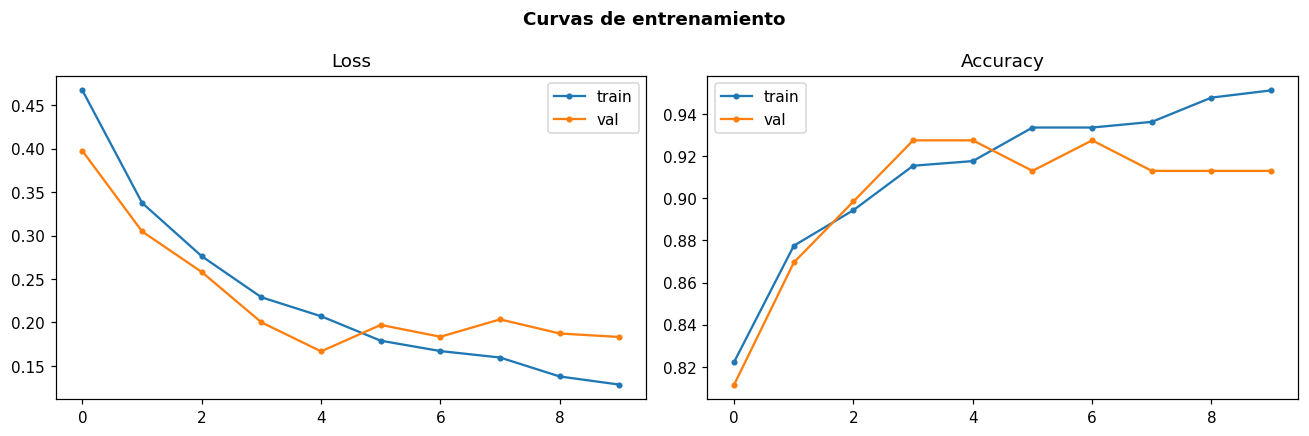

In [22]:
h = np.array(history)
fig, ax = plt.subplots(1,2,figsize=(12,4))
fig.suptitle('Curvas de entrenamiento', fontweight='bold')
ax[0].plot(h[:,0],'.-',label='train'); ax[0].plot(h[:,2],'.-',label='val')
ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(h[:,1],'.-',label='train'); ax[1].plot(h[:,3],'.-',label='val')
ax[1].set_title('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR/'10_training_curves.png'); plt.show()

## 6 · Evaluación base

> ⚠️ Test set = **70 imágenes** — resultado del split por pseudo-paciente del pipeline.  
> Las métricas son orientativas. Cada imagen en test vale ~1.4% de accuracy.

In [23]:
def predict(model, loader):
    model.eval()
    probs, labels, paths = [], [], []
    with torch.no_grad():
        for imgs, lbs, ps in loader:
            probs.append(F.softmax(model(imgs.to(DEVICE)),1).cpu().numpy())
            labels.extend(lbs.numpy()); paths.extend(ps)
    return np.vstack(probs), np.array(labels), paths

test_probs, test_labels, test_paths = predict(model, test_dl)
test_preds = test_probs.argmax(1)

print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))
print('AUC por clase (OvR):')
for i, cls in enumerate(CLASSES):
    b = (test_labels==i).astype(int)
    if 0 < b.sum() < len(b):
        print(f'  {cls:<25}: {roc_auc_score(b, test_probs[:,i]):.3f}')

                      precision    recall  f1-score   support

            cataract      0.846     0.917     0.880        12
diabetic_retinopathy      0.960     1.000     0.980        24
            glaucoma      0.923     0.800     0.857        15
              normal      0.933     0.933     0.933        15

            accuracy                          0.924        66
           macro avg      0.916     0.913     0.913        66
        weighted avg      0.925     0.924     0.923        66

AUC por clase (OvR):
  cataract                 : 0.985
  diabetic_retinopathy     : 0.995
  glaucoma                 : 0.986
  normal                   : 0.995


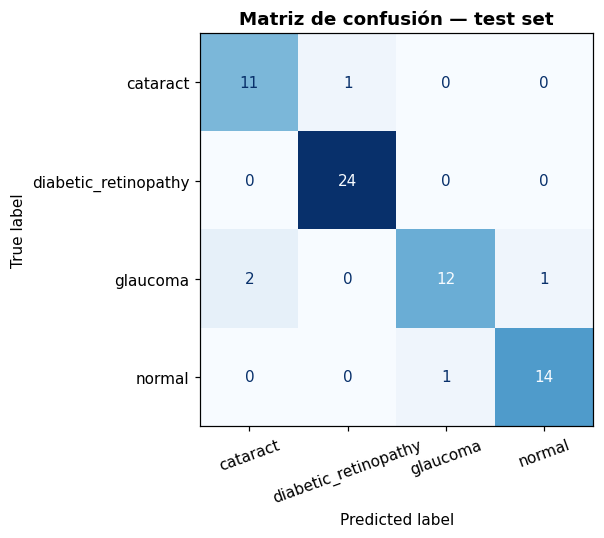

In [24]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(test_labels, test_preds),
                       display_labels=CLASSES).plot(ax=ax, colorbar=False,
                       cmap='Blues', xticks_rotation=20)
ax.set_title('Matriz de confusión — test set', fontweight='bold')
plt.tight_layout(); plt.savefig(RESULTS_DIR/'11_confusion_matrix.png'); plt.show()

## 7 · Grad-CAM — Explicabilidad

El calor debe concentrarse sobre **disco óptico, vasos retinales o opacidades del cristalino**.  
Si cae en los bordes negros del fundus → el modelo aprendió el artefacto de cámara, no la lesión.

La celda de test de integridad lo verifica automáticamente.

In [25]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.grads = None; self.acts = None
        target_layer.register_forward_hook(lambda m,i,o: setattr(self,'acts',o.detach()))
        target_layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'grads',go[0].detach()))
        self.model = model

    def __call__(self, img_t, cls=None):
        self.model.eval()
        logits = self.model(img_t.unsqueeze(0).to(DEVICE))
        cls    = cls if cls is not None else logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, cls].backward()
        weights = self.grads.mean(dim=(2,3), keepdim=True)
        cam     = F.relu((weights * self.acts).sum(dim=1)).squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, cls

gradcam = GradCAM(model, model.features[-1])
print('GradCAM listo — hook en model.features[-1] ✓')

GradCAM listo — hook en model.features[-1] ✓


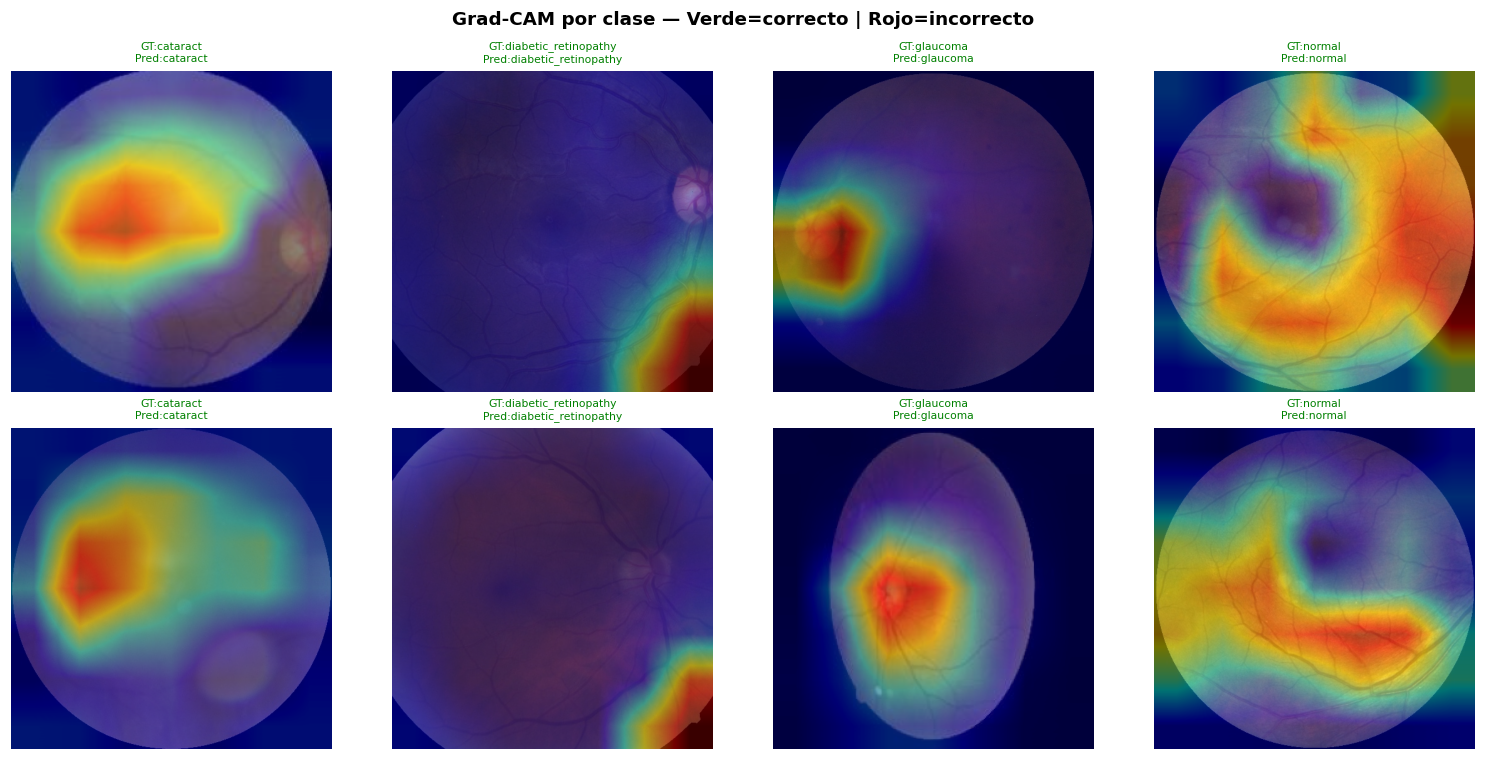

In [26]:
def overlay_cam(img_path, cam):
    img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    heat = cv2.cvtColor(cv2.applyColorMap(
        cv2.resize((cam*255).astype(np.uint8),(w,h)), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return (0.55*img + 0.45*heat).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Grad-CAM por clase — Verde=correcto | Rojo=incorrecto', fontweight='bold')

for col, cls_idx in enumerate(range(N_CLASSES)):
    idxs = np.where(test_labels==cls_idx)[0][:2]
    for row, idx in enumerate(idxs):
        cam, pred = gradcam(EVAL_TF(cv2.cvtColor(cv2.imread(test_paths[idx]),cv2.COLOR_BGR2RGB)))
        axes[row][col].imshow(overlay_cam(test_paths[idx], cam))
        axes[row][col].axis('off')
        ok = pred==test_labels[idx]
        axes[row][col].set_title(
            f'GT:{CLASSES[cls_idx]}\nPred:{CLASSES[pred]}',
            fontsize=7, color='green' if ok else 'red')
    if len(idxs)<2: axes[1][col].axis('off')

plt.tight_layout(); plt.savefig(RESULTS_DIR/'12_gradcam.png', bbox_inches='tight'); plt.show()

In [27]:
# ── Test de integridad: ¿el calor está dentro de la retina? ──────────────────
def artefact_score(img_path, cam_fn, thresh=0.5):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    cam, _ = cam_fn(EVAL_TF(img))
    cam_r  = cv2.resize(cam, (img.shape[1], img.shape[0]))
    black  = img.mean(2) < 15
    hi_cam = cam_r > thresh
    return float((black & hi_cam).sum() / (hi_cam.sum() + 1e-8))

sample = np.random.choice(len(test_paths), min(40, len(test_paths)), replace=False)
scores = [artefact_score(test_paths[i], gradcam) for i in sample]
mean_s = np.mean(scores)
print(f'Atención en bordes negros: media={mean_s:.3f} | max={max(scores):.3f}')
if mean_s > 0.15:
    print('  ⚠  >15% de atención fuera de retina → modelo puede haber aprendido artefactos')
    print('     Acción: añadir crop circular en preprocesado (enmascarar bordes negros)')
else:
    print('  ✓  Atención concentrada dentro de la retina')

Atención en bordes negros: media=0.147 | max=0.843
  ✓  Atención concentrada dentro de la retina


## 8 · Monte Carlo Dropout — Incertidumbre clínica

Un modelo que siempre predice con 95% de confianza es peligroso en clínica.  
MC Dropout estima cuándo el modelo genuinamente "no sabe".

Los casos con entropía > P90 se guardan en `uncertain_cases.csv`  
para revisión humana — flujo estándar en sistemas de IA médica asistida.

In [28]:
def enable_mc_dropout(model):
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout): m.train()

def mc_predict(model, loader, n=30):
    enable_mc_dropout(model)
    runs = []
    for _ in tqdm(range(n), desc='MC passes', leave=False):
        ps, ls, pths = [], [], []
        with torch.no_grad():
            for imgs, labels, paths in loader:
                ps.append(F.softmax(model(imgs.to(DEVICE)),1).cpu().numpy())
                ls.extend(labels.numpy()); pths.extend(paths)
        runs.append(np.vstack(ps))
    runs    = np.stack(runs)
    mean_p  = runs.mean(0)
    std_p   = runs.std(0)
    entropy = -(mean_p * np.log(mean_p + 1e-9)).sum(1)
    return mean_p, std_p, entropy, np.array(ls), pths

mc_probs, mc_std, mc_entropy, mc_labels, mc_paths = mc_predict(model, test_dl, n=30)
mc_preds = mc_probs.argmax(1)
print(f'Accuracy MC Dropout : {(mc_preds==mc_labels).mean():.3f}')
print(f'Entropía media      : {mc_entropy.mean():.3f} ± {mc_entropy.std():.3f}')

MC passes:   0%|          | 0/30 [00:00<?, ?it/s]

Accuracy MC Dropout : 0.924
Entropía media      : 0.165 ± 0.243


In [29]:
THRESH    = np.percentile(mc_entropy, 90)
uncertain = mc_entropy > THRESH

cert_acc = (mc_preds[~uncertain] == mc_labels[~uncertain]).mean()
unc_acc  = (mc_preds[uncertain]  == mc_labels[uncertain]).mean() if uncertain.sum()>0 else float('nan')

print(f'Umbral P90          : {THRESH:.3f}')
print(f'Casos a revisar     : {uncertain.sum()} / {len(mc_labels)}  ({100*uncertain.mean():.0f}%)')
print(f'Accuracy confiados  : {cert_acc:.3f}')
print(f'Accuracy inciertos  : {unc_acc:.3f}  <- debe ser < confiados')

if uncertain.sum() > 0:
    pd.DataFrame({
        'true':     [CLASSES[l] for l in mc_labels[uncertain]],
        'pred':     [CLASSES[p] for p in mc_preds[uncertain]],
        'entropy':  mc_entropy[uncertain].round(3),
        'max_prob': mc_probs[uncertain].max(1).round(3),
        'path':     [mc_paths[i] for i in np.where(uncertain)[0]]
    }).to_csv(RESULTS_DIR/'uncertain_cases.csv', index=False)
    print('  Guardado: uncertain_cases.csv')

Umbral P90          : 0.607
Casos a revisar     : 7 / 66  (11%)
Accuracy confiados  : 0.932
Accuracy inciertos  : 0.857  <- debe ser < confiados
  Guardado: uncertain_cases.csv


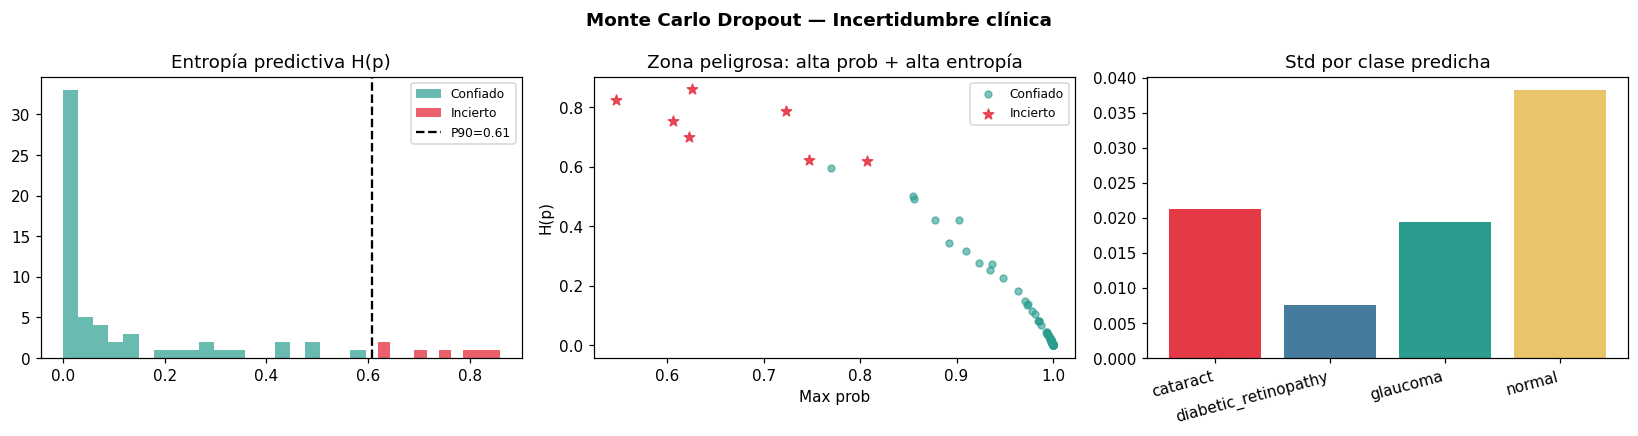

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('Monte Carlo Dropout — Incertidumbre clínica', fontweight='bold')

axes[0].hist(mc_entropy[~uncertain], bins=20, alpha=0.7, color='#2A9D8F', label='Confiado')
axes[0].hist(mc_entropy[uncertain],  bins=10, alpha=0.8, color='#E63946', label='Incierto')
axes[0].axvline(THRESH, color='black', ls='--', label=f'P90={THRESH:.2f}')
axes[0].set_title('Entropía predictiva H(p)'); axes[0].legend(fontsize=8)

axes[1].scatter(mc_probs.max(1)[~uncertain], mc_entropy[~uncertain], c='#2A9D8F', s=20, alpha=0.6, label='Confiado')
axes[1].scatter(mc_probs.max(1)[uncertain],  mc_entropy[uncertain],  c='#E63946', s=50, alpha=0.9, marker='*', label='Incierto')
axes[1].set_xlabel('Max prob'); axes[1].set_ylabel('H(p)')
axes[1].set_title('Zona peligrosa: alta prob + alta entropía'); axes[1].legend(fontsize=8)

std_cls = [mc_std[mc_preds==i].mean(0).max() for i in range(N_CLASSES)]
axes[2].bar(CLASSES, std_cls, color=['#E63946','#457B9D','#2A9D8F','#E9C46A'])
axes[2].set_title('Std por clase predicha'); axes[2].set_xticklabels(CLASSES, rotation=15, ha='right')

plt.tight_layout(); plt.savefig(RESULTS_DIR/'13_mc_dropout.png', bbox_inches='tight'); plt.show()

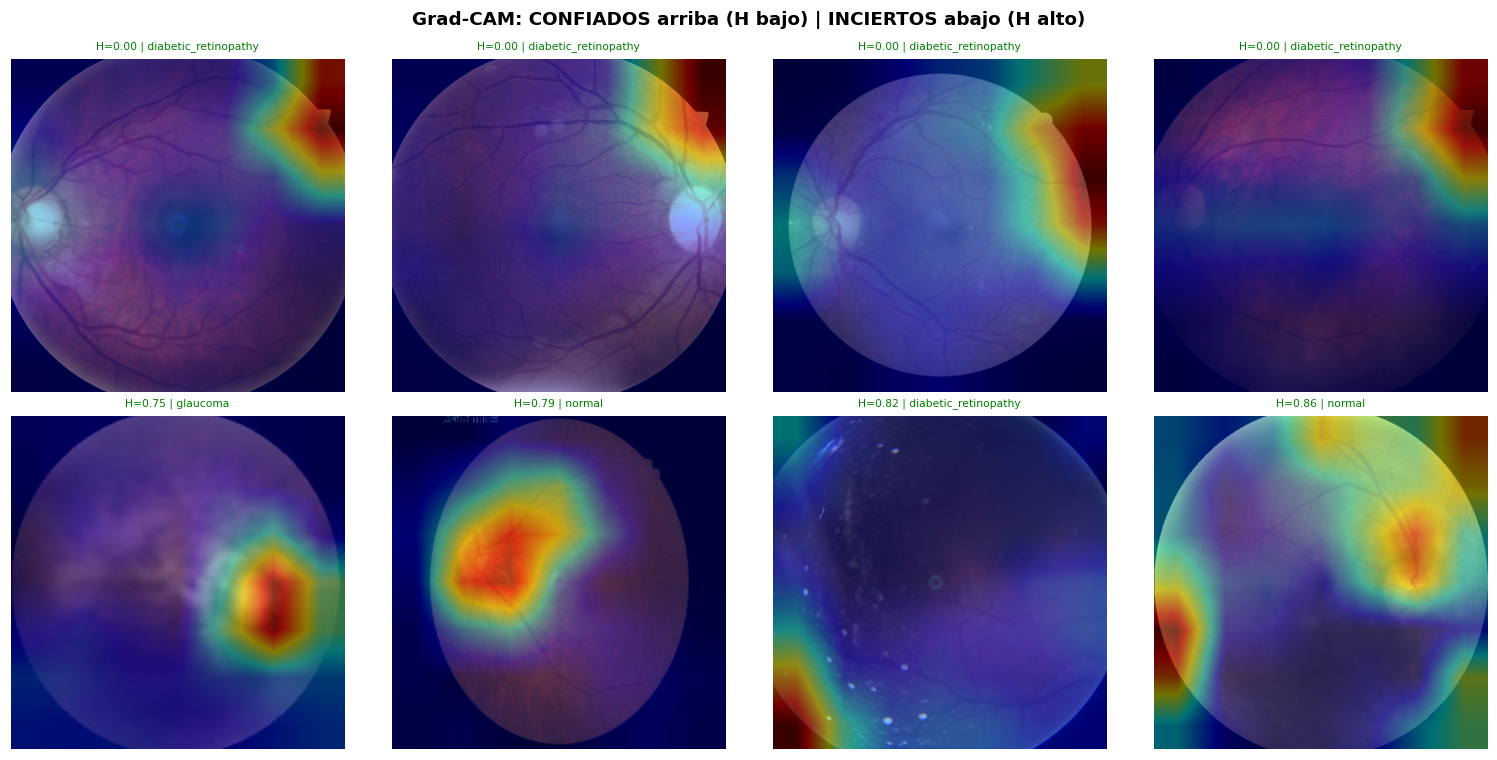

In [31]:
# Grad-CAM confiados vs inciertos
sorted_idx = np.argsort(mc_entropy)
conf_idx, unc_idx = sorted_idx[:4], sorted_idx[-4:]

fig, axes = plt.subplots(2, 4, figsize=(14,7))
fig.suptitle('Grad-CAM: CONFIADOS arriba (H bajo) | INCIERTOS abajo (H alto)', fontweight='bold')

for row, idxs in enumerate([conf_idx, unc_idx]):
    for col, idx in enumerate(idxs):
        cam, pred = gradcam(EVAL_TF(cv2.cvtColor(cv2.imread(mc_paths[idx]),cv2.COLOR_BGR2RGB)))
        axes[row][col].imshow(overlay_cam(mc_paths[idx], cam)); axes[row][col].axis('off')
        ok = pred==mc_labels[idx]
        axes[row][col].set_title(f'H={mc_entropy[idx]:.2f} | {CLASSES[mc_labels[idx]]}',
                                 fontsize=7, color='green' if ok else 'red')
plt.tight_layout(); plt.savefig(RESULTS_DIR/'14_gradcam_uncertainty.png', bbox_inches='tight'); plt.show()

## 9 · Evaluación por cluster de fuente *(opcional)*

Requiere haber subido `clustered_index.csv` en la sección 3.  
El pipeline detectó sesgo moderado (Cramér's V = 0.319):  
esta sección revela si el modelo falla específicamente en alguna fuente de cámara.

 cluster_id  n  acc        H
         29  1  0.0 0.499914
        280  1  0.0 0.036567
         57  2  0.5 0.307257
         25  2  0.5 0.686244
        355  2  0.5 0.309546
         39  1  1.0 0.008221
         14  1  1.0 0.014975
          8  1  1.0 0.000382
         49  1  1.0 0.000513
         66  1  1.0 0.253227
         71  1  1.0 0.420108
         78  1  1.0 0.012004
         84  1  1.0 0.037832
         96  1  1.0 0.000324
         40  1  1.0 0.020043
          1  2  1.0 0.052892
        113  1  1.0 0.001546
        120  1  1.0 0.029658
        126  1  1.0 0.004827
        133  1  1.0 0.005441
        139  1  1.0 0.000050
        147  1  1.0 0.135445
        155  1  1.0 0.000808
        161  1  1.0 0.114172
        169  1  1.0 0.004471
        175  1  1.0 0.017400
        184  1  1.0 0.000149
        187  1  1.0 0.009955
        199  1  1.0 0.822708
        203  1  1.0 0.079628
        101  1  1.0 0.002931
        106  1  1.0 0.000006
        217  1  1.0 0.000256
        210  1

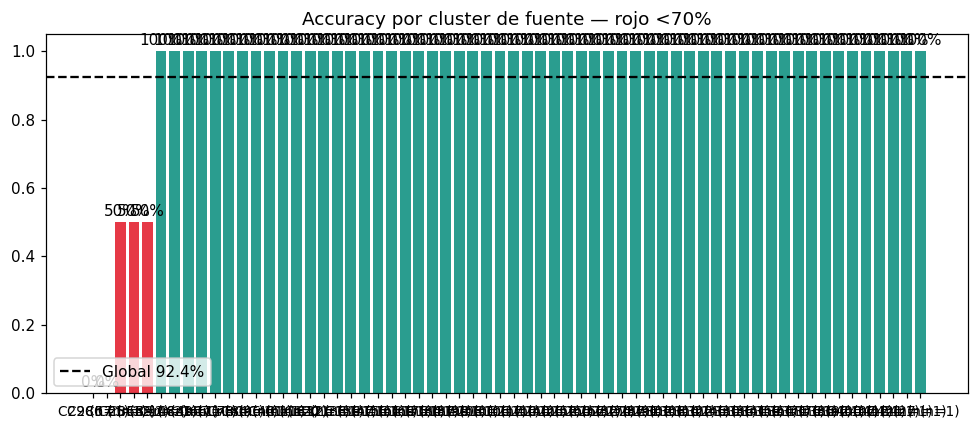

In [32]:
cluster_csv = RESULTS_DIR/'clustered_index.csv'
if not cluster_csv.exists():
    print('clustered_index.csv no encontrado — omitir o subir en sección 3')
else:
    cl = pd.read_csv(cluster_csv, usecols=['path','cluster_id'])
    res = pd.DataFrame({
        'path':    mc_paths, 'true': mc_labels, 'pred': mc_preds,
        'entropy': mc_entropy, 'correct': mc_preds==mc_labels,
    }).merge(cl, on='path', how='left')
    res['cluster_id'] = res['cluster_id'].fillna(-1).astype(int)

    perf = (res.groupby('cluster_id')
              .agg(n=('correct','count'), acc=('correct','mean'), H=('entropy','mean'))
              .reset_index().sort_values('acc'))
    print(perf.to_string(index=False))

    fig, ax = plt.subplots(figsize=(9,4))
    bars = ax.bar(range(len(perf)), perf['acc'],
                  color=['#E63946' if v<0.7 else '#2A9D8F' for v in perf['acc']])
    ax.bar_label(bars, labels=[f'{v:.0%}' for v in perf['acc']], padding=2)
    ax.set_xticks(range(len(perf)))
    ax.set_xticklabels([f'C{c} (n={n})' for c,n in zip(perf['cluster_id'],perf['n'])], fontsize=9)
    ax.axhline(res['correct'].mean(), color='black', ls='--',
               label=f"Global {res['correct'].mean():.1%}")
    ax.set_title('Accuracy por cluster de fuente — rojo <70%'); ax.legend()
    plt.tight_layout(); plt.savefig(RESULTS_DIR/'15_accuracy_by_source.png'); plt.show()
    res.to_csv(RESULTS_DIR/'test_predictions.csv', index=False)

## 10 · Descargar resultados

In [33]:
import shutil

shutil.make_archive('/content/eye_disease_results', 'zip', '/content/results')

from google.colab import files
files.download('/content/eye_disease_results.zip')
print('Descargando resultados...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargando resultados...


## Resumen

In [34]:
print('='*55)
print('  RESUMEN CV/ML ENGINEER')
print('='*55)
acc = (mc_preds==mc_labels).mean()
print(f'  Modelo        : EfficientNetB0 (ImageNet pretrained)')
print(f'  Test accuracy : {acc:.3f}  (n={len(mc_labels)})')
print(f'  MC Dropout    : 30 passes | umbral P90={THRESH:.3f}')
print(f'  A revisar     : {uncertain.sum()} casos ({100*uncertain.mean():.0f}%)')
print(f'  Acc confiados : {cert_acc:.3f}  |  inciertos: {unc_acc:.3f}')
print()
print('  Archivos en /content/results/:')
for f in sorted(Path('/content/results').iterdir()):
    if f.stat().st_size > 0:
        print(f'    {f.name:<40} {f.stat().st_size//1024} KB')
print('='*55)

  RESUMEN CV/ML ENGINEER
  Modelo        : EfficientNetB0 (ImageNet pretrained)
  Test accuracy : 0.924  (n=66)
  MC Dropout    : 30 passes | umbral P90=0.607
  A revisar     : 7 casos (11%)
  Acc confiados : 0.932  |  inciertos: 0.857

  Archivos en /content/results/:
    10_training_curves.png                   56 KB
    11_confusion_matrix.png                  33 KB
    12_gradcam.png                           884 KB
    13_mc_dropout.png                        66 KB
    14_gradcam_uncertainty.png               964 KB
    15_accuracy_by_source.png                42 KB
    clustered_index.csv                      2252 KB
    efficientnet_best.pth                    15969 KB
    split_index.csv                          305 KB
    test_predictions.csv                     5 KB
    uncertain_cases.csv                      0 KB
